Cargando 403 imágenes de cardboard...
Cargando 501 imágenes de glass...
Cargando 410 imágenes de metal...
Cargando 594 imágenes de paper...
Cargando 482 imágenes de plastic...
Cargando 137 imágenes de trash...


C:\Users\victo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │       393,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 393,446 (1.50 MB)

 Trainable params: 393,446 (1.50 MB)

 Non-trainable params: 0 (0.00 B)


Entrenando Red Neuronal Simple...
Epoch 1/25
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.1815 - loss: 2.2314 - val_accuracy: 0.1621 - val_loss: 1.7880
Epoch 2/25
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2257 - loss: 1.7844 - val_accuracy: 0.2352 - val_loss: 1.7808
Epoch 3/25
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2350 - loss: 1.7776 - val_accuracy: 0.2352 - val_loss: 1.7745
Epoch 4/25
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2350 - loss: 1.7715 - val_accuracy: 0.2352 - val_loss: 1.7689
Epoch 5/25
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2350 - loss: 1.7662 - val_accuracy: 0.2352 - val_loss: 1.7637
Epoch 6/25
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2350 - loss: 1.7613 - val_accuracy: 0.2352 - val_loss: 1.7593
Epoch 7/25
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2350 - loss: 1.7570 - val_accuracy: 0.2352 - val_loss: 1.7553
Epoch 8/25
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2350 - loss: 1.7531

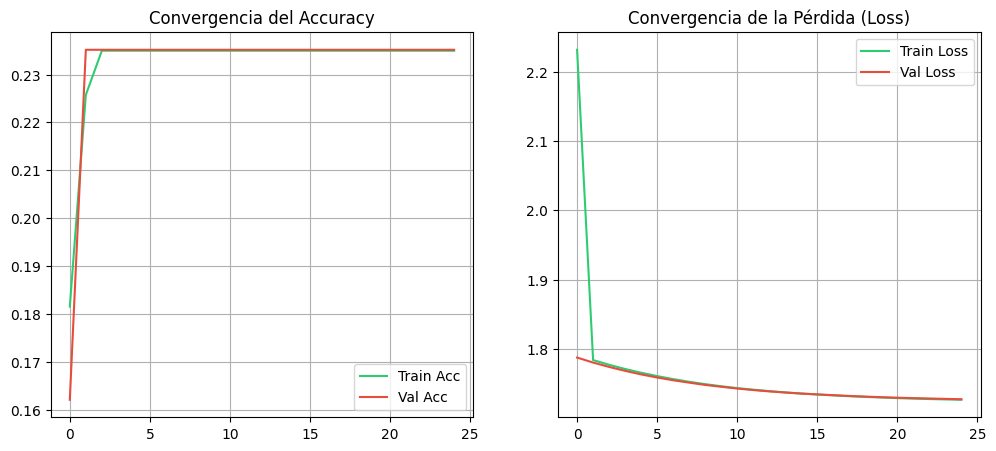

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
import glob
from PIL import Image 
from sklearn.model_selection import train_test_split

# Cargamos el modelo desde el archivo .py
sys.path.append(os.path.abspath('.'))
from modelos.modelo_simple import obtener_modelo

# Carga y preprocesamiento
PATH_DATOS = 'data/' 
IMG_SIZE = (64, 64) 

def cargar_datos(path):
    X_list, y_list = [], []
    
    if not os.path.exists(path):
        print(f"Error: No se encuentra la carpeta {path}")
        return np.array([]), np.array([]), []
        
    categorias = sorted([d for d in os.listdir(path) if os.path.isdir(os.path.join(path, d))])
    for idx, cat in enumerate(categorias):
        files = glob.glob(os.path.join(path, cat, '*'))
        print(f"Cargando {len(files)} imágenes de {cat}...")
        for f in files:
            try:
                img = Image.open(f).convert('RGB').resize(IMG_SIZE)
                X_list.append(np.array(img))
                y_list.append(idx)
            except: continue
            
    return np.array(X_list), np.array(y_list), categorias

# Carga inicial
X_img, y, nombres_clases = cargar_datos(PATH_DATOS)

if X_img.size == 0:
    print("ERROR: No se cargaron imágenes. Revisa la carpeta 'data/'.")
else:
    X_norm = X_img / 255.0

    # División de los datos (60% Train, 20% Val, 20% Test)
    X_train_val, X_test, y_train_val, y_test = train_test_split(
        X_norm, y, test_size=0.2, random_state=42, stratify=y
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_val, y_train_val, test_size=0.25, random_state=42, stratify=y_train_val
    )

    # Cargamos el modelo
    input_shape = X_train.shape[1:] 
    num_classes = len(nombres_clases)
    model = obtener_modelo(input_shape, num_classes)

    model.summary()
    num_params = model.count_params()

    # Entrenamos el modelo
    print("\nEntrenando Red Neuronal Simple...")
    history = model.fit(X_train, y_train, 
                        epochs=25, 
                        batch_size=32, 
                        validation_data=(X_val, y_val),
                        verbose=1)

    # Evaluación del modelo
    acc_train = model.evaluate(X_train, y_train, verbose=0)[1]
    acc_val = model.evaluate(X_val, y_val, verbose=0)[1]
    acc_test = model.evaluate(X_test, y_test, verbose=0)[1]

    print(f"\n{'='*30}\n RESULTADOS PARA LA TABLA \n{'='*30}")
    print(f"Parámetros totales: {num_params}")
    print(f"Accuracy Train: {acc_train:.4f}")
    print(f"Accuracy Val:   {acc_val:.4f}")
    print(f"Accuracy Test:  {acc_test:.4f}")

    # Dibujamos las curvas de entrenamiento
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Acc', color='#2ecc71')
    plt.plot(history.history['val_accuracy'], label='Val Acc', color='#e74c3c')
    plt.title('Convergencia del Accuracy')
    plt.legend(); plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss', color='#2ecc71')
    plt.plot(history.history['val_loss'], label='Val Loss', color='#e74c3c')
    plt.title('Convergencia de la Pérdida (Loss)')
    plt.legend(); plt.grid(True)
    plt.show()